In [1]:
import os, shutil, tempfile
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0' # Fixes a warning from Pytorch
import torch
import numpy as np

import matplotlib.pyplot as plt
from monai.apps import DecathlonDataset
from monai.config import print_config
from monai.data import DataLoader
from monai.losses import DiceLoss, DiceCELoss
from monai.metrics import DiceMetric
from monai.networks.nets import UNet
from monai.transforms import (
    Activations,
    EnsureChannelFirstd,
    AsDiscrete,
    CenterSpatialCropd,
    Compose,
    LoadImaged,
    MapTransform,
    NormalizeIntensityd,
    Orientationd,
    RandFlipd,
    RandScaleIntensityd,
    RandShiftIntensityd,
    RandSpatialCropd,
    Spacingd,
    ToTensord,
)
from monai.utils import set_determinism
%matplotlib inline

print_config()

2026-02-23 18:28:44.084228: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


MONAI version: 1.6.dev2608
Numpy version: 2.4.2
Pytorch version: 2.10.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: f706d259b4ee37b581784b8f13fbf80cb4e00fe6
MONAI __file__: /home/<username>/regis/virtual/python3.13/lib64/python3.13/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: 5.4.5
Nibabel version: 5.3.3
scikit-image version: 0.26.0
scipy version: 1.17.1
Pillow version: 12.1.1
Tensorboard version: 2.20.0
gdown version: 5.2.1
TorchVision version: 0.25.0+cu128
tqdm version: 4.67.3
lmdb version: 1.7.5
psutil version: 7.2.2
pandas version: 3.0.1
einops version: 0.8.2
transformers version: 5.1.0
mlflow version: 3.10.0
pynrrd version: 1.1.3
clearml version: 2.1.3

For details about installing the optional dependencies, please visit:
    https://monai.readthedocs.io/en/latest/installation.html#installing-the-recommended-dependencies



In [2]:
root_dir = '../monai'
set_determinism(seed=42)
roi_size = [128, 128, 64]
pixdim = (1.5, 1,5, 2.0)
cache_num = 8
slice_id = 31

In [3]:
class ConvertToMultiChannelBasedOnBratsClassesd(MapTransform):
    '''
    Convert labels to multi channels based on brats classes:
    label 1 is the peritumoral edema
    label 2 is the GD-enhancing tumor
    label 3 is the necrotic and non-enhancing tumor core
    The possible classes are TC (Tumor core), WT (Whole tumor)
    and ET (Enhancing tumor).

    '''

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            result = []
            # merge label 2 and label 3 to construct TC
            result.append(np.logical_or(d[key] == 2, d[key] == 3))
            # merge labels 1, 2 and 3 to construct WT
            result.append(
                np.logical_or(
                    np.logical_or(d[key] == 2, d[key] == 3), d[key] == 1
                )
            )
            # label 2 is ET
            result.append(d[key] == 2)
            d[key] = np.stack(result, axis=0).astype(np.float32)
        return d

In [4]:
train_transform = Compose(
    [
        # load 4 Nifti images and stack them together
        LoadImaged(keys=['image', 'label']),
        EnsureChannelFirstd(keys='image'),
        ConvertToMultiChannelBasedOnBratsClassesd(keys='label'),
        Spacingd(
            keys=['image', 'label'],
            pixdim=pixdim,
            mode=('bilinear', 'nearest'),
        ),
        Orientationd(keys=['image', 'label'], axcodes='RAS'),
        RandSpatialCropd(
            keys=['image', 'label'], roi_size=roi_size, random_size=False),
        RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=0),
        NormalizeIntensityd(keys='image', nonzero=True, channel_wise=True),
        RandScaleIntensityd(keys='image', factors=0.1, prob=0.5),
        RandShiftIntensityd(keys='image', offsets=0.1, prob=0.5),
        ToTensord(keys=['image', 'label']),
    ]
)

val_transform = Compose(
    [
        LoadImaged(keys=['image', 'label']),
        EnsureChannelFirstd(keys='image'),
        ConvertToMultiChannelBasedOnBratsClassesd(keys='label'),
        Spacingd(
            keys=['image', 'label'],
            pixdim=pixdim,
            mode=('bilinear', 'nearest'),
        ),
        Orientationd(keys=['image', 'label'], axcodes='RAS'),
        CenterSpatialCropd(keys=['image', 'label'], roi_size=roi_size),
        NormalizeIntensityd(keys='image', nonzero=True, channel_wise=True),
        ToTensord(keys=['image', 'label']),
    ]
)

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


In [5]:
train_ds = DecathlonDataset(
    root_dir=root_dir,
    task='Task01_BrainTumour',
    transform=train_transform,
    section='training',
    download=True,
    num_workers=4,
    cache_num=cache_num, # it was 100 but we use larger volumes
)
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=2)
val_ds = DecathlonDataset(
    root_dir=root_dir,
    task='Task01_BrainTumour',
    transform=val_transform,
    section='validation',
    download=False,
    num_workers=4,
    cache_num=cache_num,
)
val_loader = DataLoader(val_ds, batch_size=2, shuffle=False, num_workers=2)

2026-02-23 18:28:57,253 - INFO - Verified 'Task01_BrainTumour.tar', md5: 240a19d752f0d9e9101544901065d872.
2026-02-23 18:28:57,254 - INFO - File exists: ../monai/Task01_BrainTumour.tar, skipped downloading.
2026-02-23 18:28:57,271 - INFO - Non-empty folder exists in ../monai/Task01_BrainTumour, skipped extracting.


Loading dataset: 100%|███████████████████████████████████| 8/8 [00:03<00:00,  2.63it/s]


image shape: torch.Size([4, 128, 128, 32])


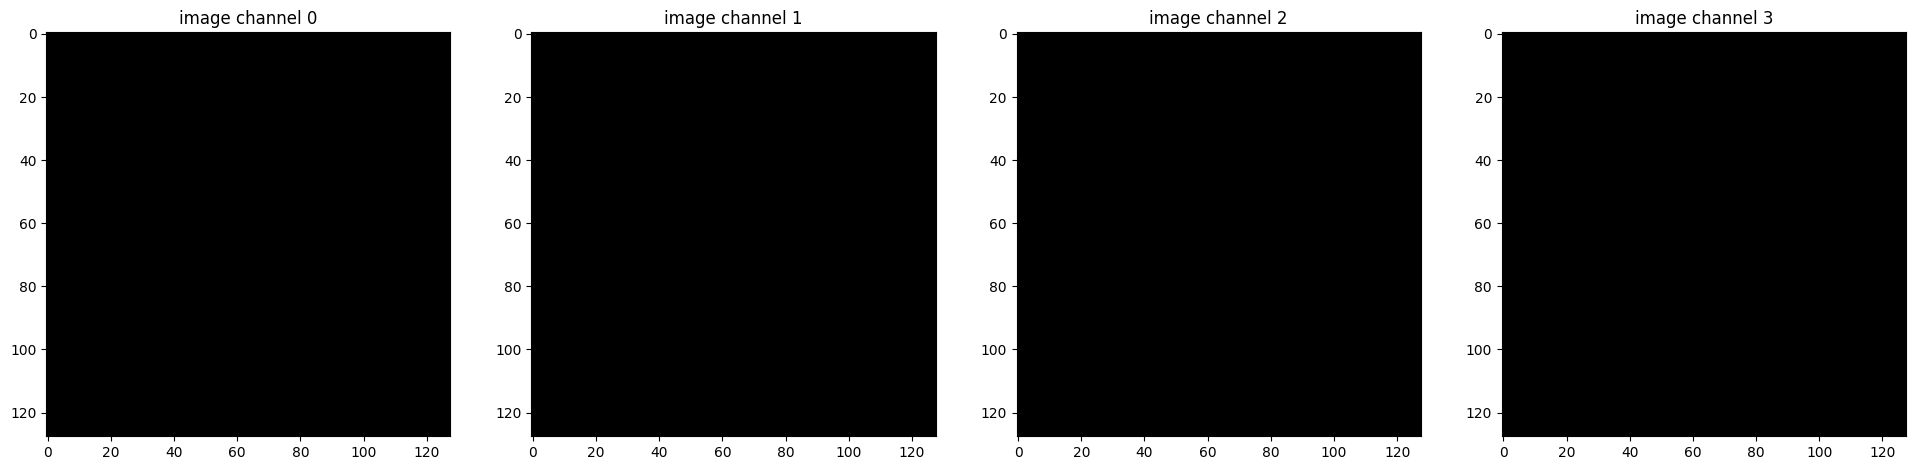

label shape: torch.Size([3, 128, 128, 32])


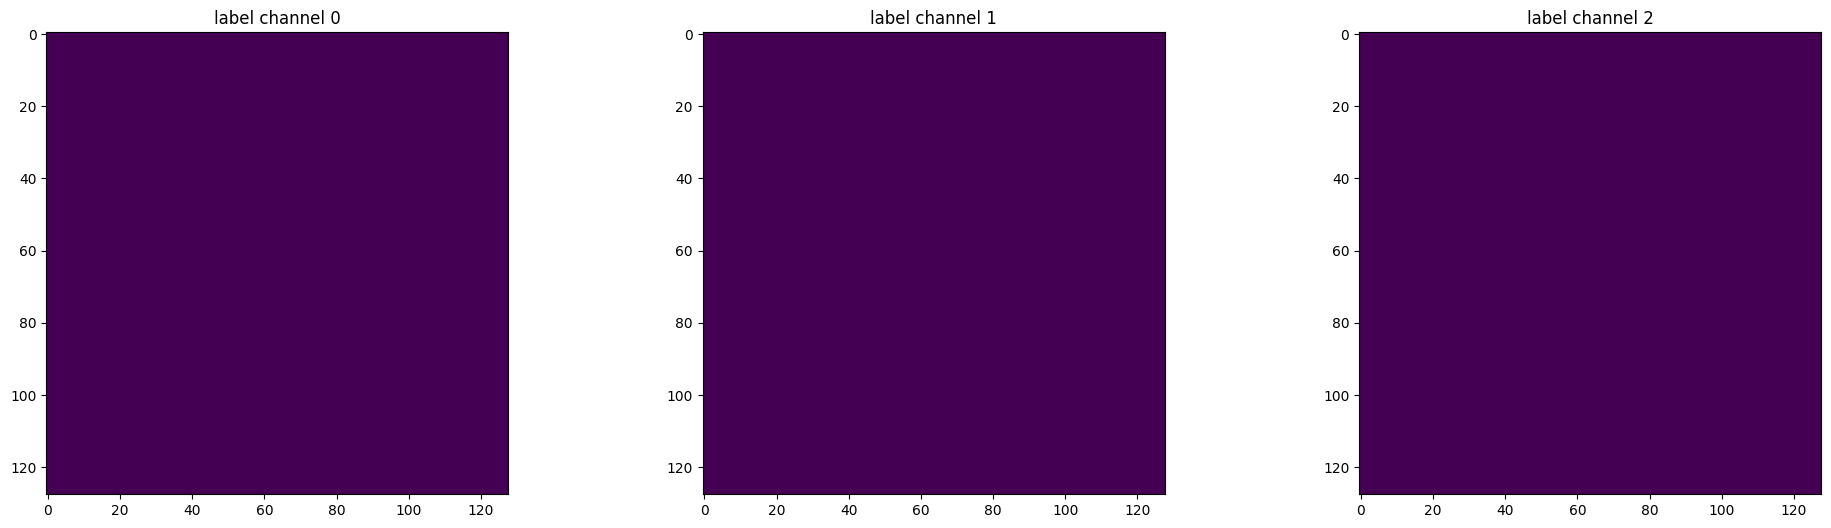

(128, 128, 32)


In [6]:
# pick one image from DecathlonDataset to visualize and check the 4 channels
print(f'image shape: {val_ds[2]['image'].shape}')
plt.figure('image', (24, 6))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.title(f'image channel {i}')
    plt.imshow(val_ds[2]['image'][i, :, :, slice_id].detach().cpu(),  cmap='gray') #
plt.show()
# also visualize the 3 channels label corresponding to this image
print(f'label shape: {val_ds[2]['label'].shape}')
plt.figure('label', (24, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.title(f'label channel {i}')
    plt.imshow(val_ds[6]['label'][i, :, :, slice_id].detach().cpu())
plt.show()

train_size = tuple(val_ds[6]['image'].shape[1:])
print(train_size)